In [ ]:
# Import libraries for transfer learning and evaluation

import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Download the Cats vs Dogs sample dataset

import requests
import zipfile

url = "https://zenodo.org/records/5226945/files/cats_dogs_light.zip?download=1"
zip_path = "/content/cats_dogs_light.zip"

response = requests.get(url)

with open(zip_path, "wb") as f:
    f.write(response.content)

print("Downloaded:", round(len(response.content) / (1024 * 1024), 2), "MB")

# Extract dataset
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/cats_dogs")

print("Dataset extracted successfully.")

Downloaded: 31.1 MB
Dataset extracted successfully.


In [ ]:
# Inspect dataset folders and count images

for root, dirs, files in os.walk("/content/cats_dogs"):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        print(root, "->", len(image_files), "images")

/content/cats_dogs/cats_dogs_light/test -> 400 images
/content/cats_dogs/cats_dogs_light/train -> 1000 images


In [ ]:
# Inspect the dataset directory structure

for root, dirs, files in os.walk("/content/cats_dogs"):
    print("\nFolder:", root)
    print("Subfolders:", dirs[:10])
    print("Sample files:", files[:5])


Folder: /content/cats_dogs
Subfolders: ['cats_dogs_light']
Sample files: []

Folder: /content/cats_dogs/cats_dogs_light
Subfolders: ['test', 'train']
Sample files: []

Folder: /content/cats_dogs/cats_dogs_light/test
Subfolders: []
Sample files: ['cat.9955.jpg', 'dog.9932.jpg', 'dog.9852.jpg', 'cat.9974.jpg', 'dog.9944.jpg']

Folder: /content/cats_dogs/cats_dogs_light/train
Subfolders: []
Sample files: ['dog.10100.jpg', 'dog.10298.jpg', 'dog.10398.jpg', 'dog.10305.jpg', 'dog.10409.jpg']


In [ ]:
# Load images and assign labels from filenames

train_dir = "/content/cats_dogs/cats_dogs_light/train"
test_dir = "/content/cats_dogs/cats_dogs_light/test"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CatDogDataset(torch.utils.data.Dataset):

    def __init__(self, directory, transform=None):
        self.files = [
            os.path.join(directory, f)
            for f in os.listdir(directory)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        path = self.files[index]
        image = datasets.folder.default_loader(path)

        label = 0 if os.path.basename(path).startswith("cat.") else 1

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = CatDogDataset(train_dir, transform)
test_dataset = CatDogDataset(test_dir, transform)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

cat_train = sum(
    os.path.basename(f).startswith("cat.")
    for f in train_dataset.files
)

dog_train = len(train_dataset) - cat_train

cat_test = sum(
    os.path.basename(f).startswith("cat.")
    for f in test_dataset.files
)

dog_test = len(test_dataset) - cat_test

print("Training - Cats:", cat_train, "Dogs:", dog_train)
print("Testing  - Cats:", cat_test, "Dogs:", dog_test)

Training images: 1000
Testing images: 400
Training - Cats: 455 Dogs: 545
Testing  - Cats: 200 Dogs: 200


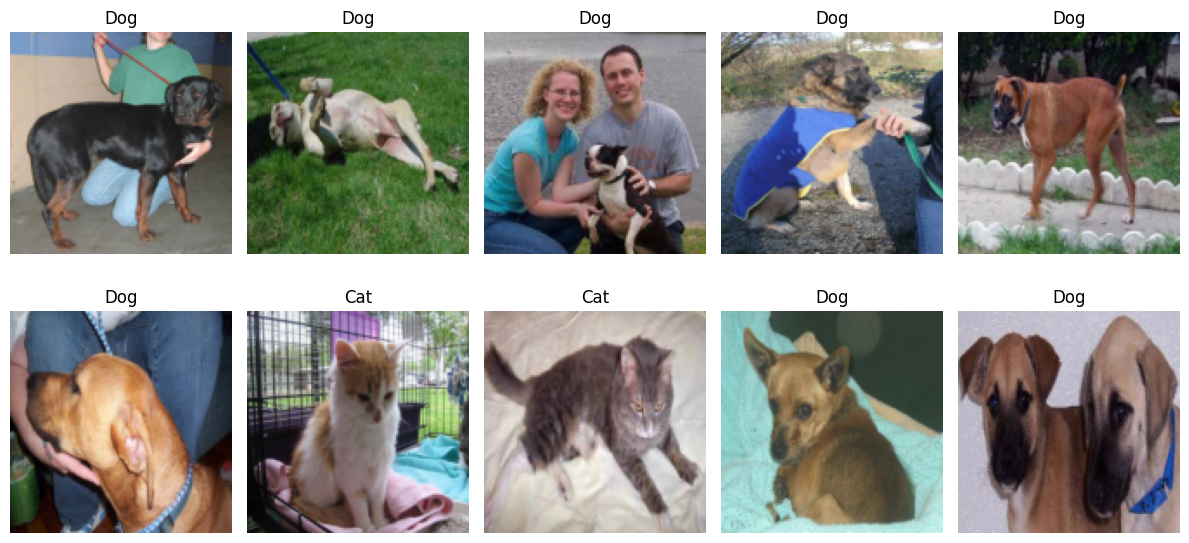

In [ ]:
# Display sample cat and dog images

plt.figure(figsize=(12, 6))

shown = 0

for i in range(len(train_dataset)):
    image, label = train_dataset[i]

    if shown >= 10:
        break

    image = image.permute(1, 2, 0).numpy()

    # Reverse ImageNet normalization for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 5, shown + 1)
    plt.imshow(image)
    plt.title("Cat" if label == 0 else "Dog")
    plt.axis("off")

    shown += 1

plt.tight_layout()
plt.show()

In [ ]:
# Create DataLoaders for training and testing

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 32
Testing batches: 13


In [ ]:
# Load pretrained ImageNet models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

weights = {
    "AlexNet": models.AlexNet_Weights.DEFAULT,
    "VGG16": models.VGG16_Weights.DEFAULT,
    "ResNet50": models.ResNet50_Weights.DEFAULT,
    "EfficientNetB0": models.EfficientNet_B0_Weights.DEFAULT
}

alexnet = models.alexnet(weights=weights["AlexNet"])
vgg16 = models.vgg16(weights=weights["VGG16"])
resnet50 = models.resnet50(weights=weights["ResNet50"])
efficientnet = models.efficientnet_b0(weights=weights["EfficientNetB0"])

print("All pretrained models loaded successfully.")

Device: cpu
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 161MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 70.3MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 111MB/s] 


All pretrained models loaded successfully.


In [ ]:
# Freeze pretrained feature extraction layers

for model in [alexnet, vgg16, resnet50, efficientnet]:
    for param in model.parameters():
        param.requires_grad = False

# Replace final classifiers for binary classification
alexnet.classifier[6] = nn.Linear(
    alexnet.classifier[6].in_features, 2
)

vgg16.classifier[6] = nn.Linear(
    vgg16.classifier[6].in_features, 2
)

resnet50.fc = nn.Linear(
    resnet50.fc.in_features, 2
)

efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, 2
)

# Move models to selected device
alexnet = alexnet.to(device)
vgg16 = vgg16.to(device)
resnet50 = resnet50.to(device)
efficientnet = efficientnet.to(device)

print("Final layers modified for Cat/Dog classification.")

Final layers modified for Cat/Dog classification.


In [ ]:
# Train a transfer learning model

def train_model(model, model_name, epochs=3):

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001
    )

    model.train()
    start_time = time.time()

    history = []

    for epoch in range(epochs):

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        history.append(epoch_accuracy)

        print(
            f"{model_name} | "
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Accuracy: {epoch_accuracy:.4f}"
        )

    training_time = time.time() - start_time

    print(
        f"{model_name} training time: "
        f"{training_time:.2f} seconds"
    )

    return history, training_time

In [ ]:
# Train AlexNet using transfer learning

alexnet_history, alexnet_time = train_model(
    alexnet,
    "AlexNet",
    epochs=3
)

AlexNet | Epoch 1/3 | Loss: 0.4011 | Accuracy: 0.8540
AlexNet | Epoch 2/3 | Loss: 0.2050 | Accuracy: 0.9230
AlexNet | Epoch 3/3 | Loss: 0.1329 | Accuracy: 0.9420
AlexNet training time: 48.38 seconds


In [ ]:
# Evaluate a trained model using classification metrics

def evaluate_model(model, model_name):

    model.eval()

    y_true = []
    y_pred = []

    start_time = time.time()

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    inference_time = time.time() - start_time

    print(f"\n{model_name} Results")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"Inference Time: {inference_time:.2f} seconds")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time": None,
        "Inference Time": inference_time
    }

In [ ]:
# Evaluate AlexNet

alexnet_result = evaluate_model(
    alexnet,
    "AlexNet"
)

alexnet_result["Training Time"] = alexnet_time


AlexNet Results
Accuracy : 0.8850
Precision: 0.8407
Recall   : 0.9500
F1-Score : 0.8920
Inference Time: 10.13 seconds


In [ ]:
# Train VGG16 using transfer learning

vgg16_history, vgg16_time = train_model(
    vgg16,
    "VGG16",
    epochs=3
)

VGG16 | Epoch 1/3 | Loss: 0.1696 | Accuracy: 0.9340
VGG16 | Epoch 2/3 | Loss: 0.0770 | Accuracy: 0.9690
VGG16 | Epoch 3/3 | Loss: 0.0695 | Accuracy: 0.9760
VGG16 training time: 658.97 seconds


In [18]:
# Evaluate VGG16 on the test dataset

vgg16_result = evaluate_model(
    vgg16,
    "VGG16"
)

vgg16_result["Training Time"] = vgg16_time


VGG16 Results
Accuracy : 0.9675
Precision: 0.9606
Recall   : 0.9750
F1-Score : 0.9677
Inference Time: 91.85 seconds


In [ ]:
# Train ResNet50 using transfer learning

resnet50_history, resnet50_time = train_model(
    resnet50,
    "ResNet50",
    epochs=3
)

ResNet50 | Epoch 1/3 | Loss: 0.3597 | Accuracy: 0.8880
ResNet50 | Epoch 2/3 | Loss: 0.1896 | Accuracy: 0.9310


In [20]:
# Train ResNet50 using transfer learning

resnet50_history, resnet50_time = train_model(
    resnet50,
    "ResNet50",
    epochs=3
)

ResNet50 | Epoch 1/3 | Loss: 0.1279 | Accuracy: 0.9670
ResNet50 | Epoch 2/3 | Loss: 0.1010 | Accuracy: 0.9730
ResNet50 | Epoch 3/3 | Loss: 0.0817 | Accuracy: 0.9780
ResNet50 training time: 273.65 seconds


In [21]:
# Evaluate ResNet50 on the test dataset

resnet50_result = evaluate_model(
    resnet50,
    "ResNet50"
)

resnet50_result["Training Time"] = resnet50_time


ResNet50 Results
Accuracy : 0.9525
Precision: 0.9502
Recall   : 0.9550
F1-Score : 0.9526
Inference Time: 43.98 seconds


In [22]:
# Train EfficientNetB0 using transfer learning

efficientnet_history, efficientnet_time = train_model(
    efficientnet,
    "EfficientNetB0",
    epochs=3
)

EfficientNetB0 | Epoch 1/3 | Loss: 0.5393 | Accuracy: 0.7560
EfficientNetB0 | Epoch 2/3 | Loss: 0.3683 | Accuracy: 0.8610
EfficientNetB0 | Epoch 3/3 | Loss: 0.3149 | Accuracy: 0.8790
EfficientNetB0 training time: 91.89 seconds


In [23]:
# Evaluate EfficientNetB0 on the test dataset

efficientnet_result = evaluate_model(
    efficientnet,
    "EfficientNetB0"
)

efficientnet_result["Training Time"] = efficientnet_time


EfficientNetB0 Results
Accuracy : 0.8775
Precision: 0.8683
Recall   : 0.8900
F1-Score : 0.8790
Inference Time: 11.18 seconds


In [24]:
# Evaluate VGG16 on the test dataset

vgg16_result = evaluate_model(
    vgg16,
    "VGG16"
)

vgg16_result["Training Time"] = vgg16_time


VGG16 Results
Accuracy : 0.9675
Precision: 0.9606
Recall   : 0.9750
F1-Score : 0.9677
Inference Time: 87.92 seconds


In [25]:
# Evaluate ResNet50 on the test dataset

resnet50_result = evaluate_model(
    resnet50,
    "ResNet50"
)

resnet50_result["Training Time"] = resnet50_time


ResNet50 Results
Accuracy : 0.9525
Precision: 0.9502
Recall   : 0.9550
F1-Score : 0.9526
Inference Time: 34.16 seconds


In [26]:
import pandas as pd

In [27]:
# Create final model comparison table

results = [
    alexnet_result,
    vgg16_result,
    resnet50_result,
    efficientnet_result
]

results_df = pd.DataFrame(results)

print(results_df.round(4))

            Model  Accuracy  Precision  Recall  F1-Score  Training Time  \
0         AlexNet    0.8850     0.8407   0.950    0.8920        48.3770   
1           VGG16    0.9675     0.9606   0.975    0.9677       658.9667   
2        ResNet50    0.9525     0.9502   0.955    0.9526       273.6505   
3  EfficientNetB0    0.8775     0.8683   0.890    0.8790        91.8904   

   Inference Time  
0         10.1288  
1         87.9167  
2         34.1568  
3         11.1835  
